In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn
import multiprocessing

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm


# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation
import importlib

# from thundersvm import SVC

Trans into torch tensor input


In [2]:
importlib.reload(DE)
importlib.reload(mpl)
from DE import DESimulation

In [3]:
file_load_once = 10
param = 0

test_DE_sim = DESimulation('DE_param_30_test.yaml')

# test_cevns_sim.pe_gain_std = 2.4e6

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = test_DE_sim.load_folder_path + \
        "muon_track/muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

In [4]:
test_DE_sim.generate_muon_points(muon_file_list)
print(test_DE_sim.time_range/3600)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 222.24it/s]


/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.0.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.1.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.2.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.3.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.4.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.5.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.6.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.7.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.8.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.9.npy
Number of muon events: 31255
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e',

In [5]:
test_DE_sim.generate_CEVNS_points()
test_DE_sim.generate_CEVNS_pattern()
test_DE_sim.CEVNS_position_recon()
test_DE_sim.generate_CEVNS_recon_pattern()
test_DE_sim.CEVNS_sp_cor()

Interpn for channel:  0
Interpn for channel:  1
Interpn for channel:  2
Interpn for channel:  3
Interpn for channel:  4
Interpn for channel:  5
Interpn for channel:  6
Interpn for channel:  7
Interpn for channel:  8
Interpn for channel:  9
Interpn for channel:  10
Interpn for channel:  11
Interpn for channel:  12
Interpn for channel:  13
Interpn for channel:  14
Interpn for channel:  15
Interpn for channel:  16
Interpn for channel:  17
Interpn for channel:  18
Interpn for channel:  19
Interpn for channel:  20
Interpn for channel:  21
Interpn for channel:  22
Interpn for channel:  23
Interpn for channel:  24
Interpn for channel:  25
Interpn for channel:  26
Interpn for channel:  27
Interpn for channel:  28
Interpn for channel:  29
Interpn for channel:  30
Interpn for channel:  31
Interpn for channel:  32
Interpn for channel:  33
Interpn for channel:  34
Interpn for channel:  35
Interpn for channel:  36
Interpn for channel:  37
Interpn for channel:  38
Interpn for channel:  39
Interpn fo

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4941/4941 [00:00<00:00, 159939.93it/s]


Start pos recon for event size:  3
(71166, 64)
71166
10000 / 71166 ,time: 0.07667279243469238
20000 / 71166 ,time: 0.07534050941467285
30000 / 71166 ,time: 0.07663393020629883
40000 / 71166 ,time: 0.07553434371948242
50000 / 71166 ,time: 0.07537174224853516
60000 / 71166 ,time: 0.07630085945129395
70000 / 71166 ,time: 0.07475614547729492
done of generating test files
Start pos recon for event size:  4
(30694, 64)
30694
10000 / 30694 ,time: 0.09004354476928711
20000 / 30694 ,time: 0.07845258712768555
30000 / 30694 ,time: 0.08066082000732422
done of generating test files
Start pos recon for event size:  5
(13920, 64)
13920
10000 / 13920 ,time: 0.07904052734375
done of generating test files
Start pos recon for event size:  6
(6369, 64)
6369
done of generating test files
Start pos recon for event size:  7
(2882, 64)
2882
done of generating test files
Start pos recon for event size:  8
(1276, 64)
1276
done of generating test files
Start pos recon for event size:  9
(549, 64)
549
done of gen

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 71166/71166 [00:04<00:00, 14594.78it/s]


平均电子数：  3.106625332202974
last_muon_id.shape:  (30694,)
last_muon_id[-10:]:  [31240 31240 31240 31240 31240 31244 31249 31249 31249 31249]
0
0 30694


...

平均电子数：  7.245903214866948
last_muon_id.shape:  (1276,)
last_muon_id[-10:]:  [31108 31114 31133 31136 31146 31154 31180 31207 31214 31214]
0
0 1276


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1276/1276 [00:00<00:00, 14427.64it/s]


平均电子数：  8.28193490309775
last_muon_id.shape:  (549,)
last_muon_id[-10:]:  [30210 30340 30363 30454 30491 30506 30572 30587 30853 30899]
0
0 549


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 549/549 [00:00<00:00, 14183.21it/s]


平均电子数：  9.242627608306426


In [6]:
# pattern 绘图
def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = DESimulation('DE_param_30_test.yaml').pmt_info,title = ""):
    artists = list()
    # cmap = mpl.cm.viridis
    # 定义灰度色图
    cmap = cm.get_cmap('gray')
    norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 4))

    grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)

    # PMT plot
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
        grid[0].add_patch(artists[pmt['ChannelID']])
        
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'ro', markersize=4 ,label = 'DE Position')
  
    # recon_pos plot
    if len(electron)>0:
        grid[0].plot(pos_recons['xd']/10, pos_recons['yd']/10, 'b*', markersize=5, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    grid[0].set_title(title)
    plt.show()
    return 0

# pattern计算
def calculate_poisson_probabilities_log(data_array, mean_array):
    data_array_int = (data_array + 0.5).astype('int')
    # 计算每个元素的对数概率
    log_probabilities = -mean_array + data_array_int * \
        np.log(mean_array) - gammaln(data_array_int + 1)
    return log_probabilities

/tmp/ipykernel_9863/2645358374.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('gray')


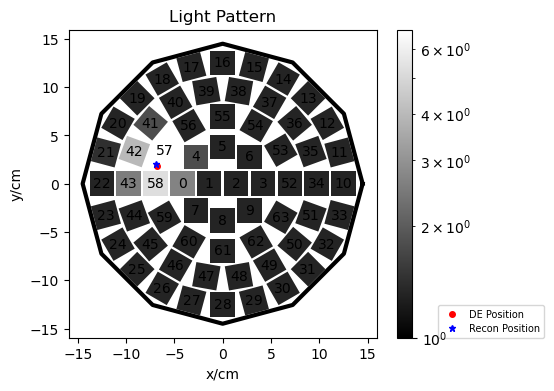

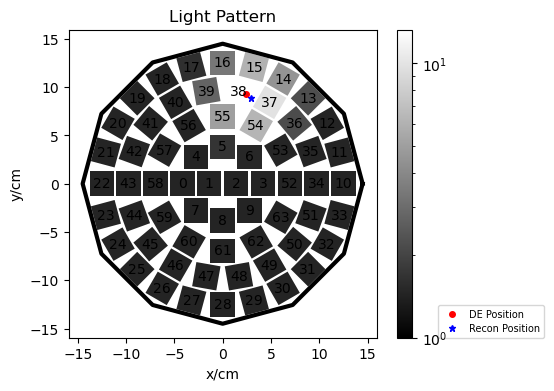

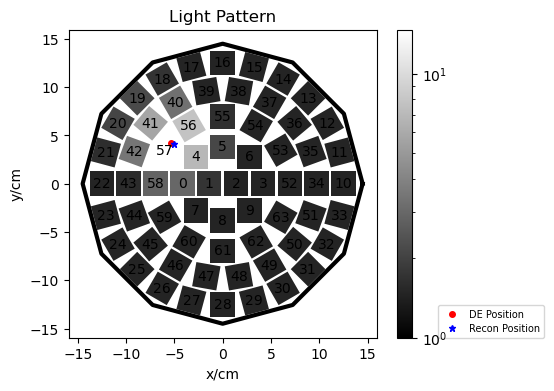

In [7]:
cevns_points = np.concatenate((test_DE_sim.cevns_points))
# 筛选出有效的sp_cor
cevns_points = cevns_points[cevns_points['st_cor'] > 0]

for i in range(100,103):
    pattern_plot(cevns_points[i]['recons_light_pattern'],
                 cevns_points[i]['pos_original'],
                 cevns_points[i]['pos_recon'],
                 title = 'Light Pattern')